In [1]:
import torch
import torch.nn.functional as F
import clip
from PIL import Image
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# TESTING_FOLDER = Path.home() / Path("Desktop/testing")
TESTING_FOLDER = Path("testing/")
METADATA_PATH = TESTING_FOLDER / "metadata.xlsx"

In [3]:
df = pd.read_excel(METADATA_PATH)
id_map = {row.Path: i for i, row in enumerate(df.itertuples(index=False))}
df["id"] = df["Path"].map(id_map)
df

,Path,Description,id
0,1.jpg,orange cat covers its face with a paw,0
1,2.jpg,dog lies in its bed,1
2,3.jpg,"a tree-shaped-like anthenna, text on the image...",2
3,4.jpg,a cat with a terrified expression on its face,3
4,5.jpg,a drawing of a dog with the bubble over its he...,4
5,6.jpg,"a comic, cat says meow to the woman, woman say...",5
6,7.jpg,image of a man with a mask and a shirt that sa...,6
7,8.jpg,tweet of graph of an lg washing machine intern...,7
8,9.jpg,"""are you winning son?"" meme",8
9,10.jpg,post about computer safety from a trans person,9


In [4]:
TOP_K = 4

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [6]:
image_embeddings = []
valid_rows = []

for row in df.itertuples(index=False):

    if not row.Path.lower().endswith(".jpg"):
        continue

    image_path = TESTING_FOLDER / row.Path

    image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model.encode_image(image)
        embedding = F.normalize(embedding, dim=-1)

    image_embeddings.append(embedding.cpu())
    valid_rows.append(row)

image_embeddings = torch.cat(image_embeddings, dim=0)

In [7]:
def reciprocal_rank(results, correct_id):
    try:
        rank = results.index(correct_id) + 1
        return 1 / rank
    except ValueError:
        return 0.0
    
def hit_at_k(results, correct_id, k):
    return int(correct_id in results[:k])

In [8]:
TOP_K = 4

N = len(df)

hit_matrices = {
    k: pd.DataFrame(
        0,
        index=range(N),
        columns=range(N),
        dtype=int
    )
    for k in range(1, TOP_K + 1)
}

hits = {k: 0 for k in range(1, TOP_K + 1)}
rr_sum = 0

In [9]:
for row in df.itertuples(index=False):
    if not row.Path.lower().endswith(".jpg"):
        continue

    current_query = row.Description
    text = clip.tokenize([current_query]).to(device)

    with torch.no_grad():
        text_embedding = model.encode_text(text)
        text_embedding = F.normalize(text_embedding, dim=-1)

    scores = (text_embedding.cpu() @ image_embeddings.T).squeeze(0)
    values, indices = torch.topk(scores, TOP_K)


    ground_truth = row

    print("=" * 120)
    print(f"QUERY (real description): {current_query}")
    print(f"GROUND TRUTH PATH: {ground_truth.Path}")
    print(f"GROUND TRUTH ID: {ground_truth.id}")
    print()
    print("TOP RESULTS:\n")

    retrieved_ids = []

    for rank, (score, idx) in enumerate(zip(values, indices), start=1):
        guess_row = valid_rows[idx.item()]
        retrieved_ids.append(guess_row.id)

        print(f"Rank {rank}")
        print(f"Path: {guess_row.Path}")
        print(f"DB Description: {guess_row.Description}")
        print(f"Score: {score.item():.6f}")
        print(f"Mapped ID: {guess_row.id}")
    
        for k in range(1, TOP_K + 1):
            if ground_truth.id in retrieved_ids[:k]:
                hit_matrices[k].loc[ground_truth.id, ground_truth.id] = 1

    rr_sum += reciprocal_rank(retrieved_ids, ground_truth.id)

    for k in range(1, TOP_K + 1):
        hits[k] += hit_at_k(retrieved_ids, ground_truth.id, k)

    hit1 = hit_at_k(retrieved_ids, ground_truth.id, 1)
    print(f"\nHIT@1: {hit1}")
    

QUERY (real description): orange cat covers its face with a paw
GROUND TRUTH PATH: 1.jpg
GROUND TRUTH ID: 0

TOP RESULTS:

Rank 1
Path: 1.jpg
DB Description: orange cat covers its face with a paw
Score: 0.265211
Mapped ID: 0
Rank 2
Path: 4.jpg
DB Description: a cat with a terrified expression on its face
Score: 0.252667
Mapped ID: 3
Rank 3
Path: 2.jpg
DB Description: dog lies in its bed
Score: 0.229327
Mapped ID: 1
Rank 4
Path: 6.jpg
DB Description: a comic, cat says meow to the woman, woman says meow back, cat is displeased
Score: 0.222742
Mapped ID: 5

HIT@1: 1
QUERY (real description): dog lies in its bed
GROUND TRUTH PATH: 2.jpg
GROUND TRUTH ID: 1

TOP RESULTS:

Rank 1
Path: 2.jpg
DB Description: dog lies in its bed
Score: 0.315752
Mapped ID: 1
Rank 2
Path: 16.jpg
DB Description: how it feels to be called annoying
Score: 0.254316
Mapped ID: 15
Rank 3
Path: 5.jpg
DB Description: a drawing of a dog with the bubble over its head with data center on fire
Score: 0.221961
Mapped ID: 4
Ra

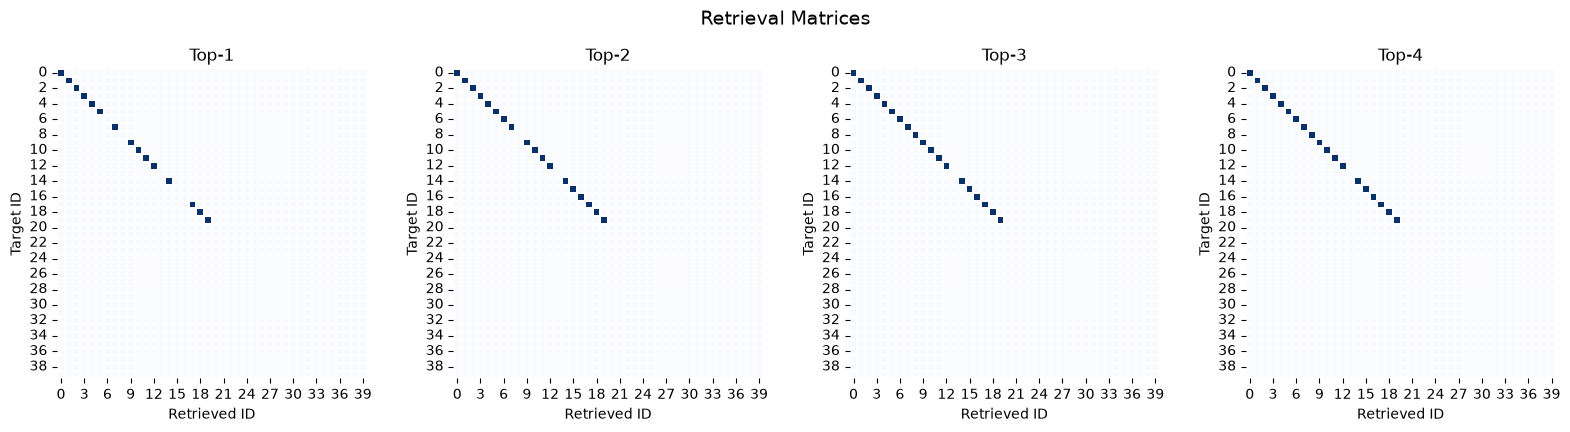

In [10]:
import math

fig_cols = TOP_K
fig_rows = math.ceil(len(hit_matrices) / fig_cols)

fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols * 4, fig_rows * 4))
axes = axes.flatten()

for idx, (k, matrix) in enumerate(hit_matrices.items()):
    sns.heatmap(
        matrix,
        ax=axes[idx],
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.2,
    )
    axes[idx].set_title(f"Top-{k}")
    axes[idx].set_xlabel("Retrieved ID")
    axes[idx].set_ylabel("Target ID")

for idx in range(len(hit_matrices), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Retrieval Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
N = 30  # test images retrieval only

print("\n===== Retrieval Summary =====")

for k in range(1, TOP_K + 1):
    print(
        f"Hit@{k}: {hits[k]}/{N} "
        f"({100 * hits[k] / N:.1f}%)"
    )

print(f"MRR: {rr_sum / N:.4f}")


===== Retrieval Summary =====
Hit@1: 15/30 (50.0%)
Hit@2: 18/30 (60.0%)
Hit@3: 19/30 (63.3%)
Hit@4: 19/30 (63.3%)
MRR: 0.5611
